# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset didapatkan dari Kaggle, sumber dari dataset ini adalah website resmi Australia yang mencatat mengenai kondisi cuaca dari berbagai lokasi disana dari tahun 2013-2017.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [93]:
#Type your code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [94]:
def load_dataset(dataset_path):
    return pd.read_csv(dataset_path)

In [95]:
df = load_dataset("../weatherAUS_raw.csv")
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [96]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  str    
 1   Location       145460 non-null  str    
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  str    
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  str    
 10  WindDir3pm     141232 non-null  str    
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null   float64


In [97]:
df_uluru = df[df['Location'] == "Uluru" ] # potong dataset karena terlalu banyak data untuk mempercepat training

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [98]:
df = df_uluru

In [99]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1578 entries, 143882 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           1578 non-null   str    
 1   Location       1578 non-null   str    
 2   MinTemp        1543 non-null   float64
 3   MaxTemp        1571 non-null   float64
 4   Rainfall       1522 non-null   float64
 5   Evaporation    0 non-null      float64
 6   Sunshine       0 non-null      float64
 7   WindGustDir    1524 non-null   str    
 8   WindGustSpeed  1524 non-null   float64
 9   WindDir9am     1512 non-null   str    
 10  WindDir3pm     1545 non-null   str    
 11  WindSpeed9am   1542 non-null   float64
 12  WindSpeed3pm   1548 non-null   float64
 13  Humidity9am    1563 non-null   float64
 14  Humidity3pm    1574 non-null   float64
 15  Pressure9am    1568 non-null   float64
 16  Pressure3pm    1574 non-null   float64
 17  Cloud9am       348 non-null    float64
 18  Cloud3pm    

In [100]:
# df["Date"] = pd.to_datetime(df["Date"])
# df["Year"] = df["Date"].dt.year
# df["Month"] = df["Date"].dt.month
# df["Day"] = df["Date"].dt.day

# def get_season(month):
#     if month in [12, 1, 2]:
#         return "Summer"
#     elif month in [3, 4, 5]:
#         return "Autumn"
#     elif month in [6, 7, 8]:
#         return "Winter"
#     else:
#         return "Spring"

# df["Season"] = df["Month"].apply(get_season)

In [101]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,1543.000000,1571.000000,1522.000000,0.0,0.0,1524.000000,1542.000000,1548.000000,1563.000000,1574.000000,1568.000000,1574.000000,348.000000,417.000000,1563.000000,1574.000000
mean,14.466688,30.383195,0.784363,NaN,NaN,41.268373,17.616732,17.028424,42.664107,24.127700,1017.101403,1013.307751,5.543103,4.834532,21.012348,29.054511
std,7.446991,7.589052,4.706608,NaN,NaN,10.876289,7.893207,6.911891,21.835443,16.176618,6.384780,6.411469,2.662772,2.798344,7.719096,7.329672
min,-1.900000,11.300000,0.000000,NaN,NaN,19.000000,0.000000,0.000000,5.000000,3.000000,994.600000,989.200000,1.000000,0.000000,5.000000,8.500000
25%,8.200000,23.800000,0.000000,NaN,NaN,33.000000,11.000000,11.000000,25.000000,13.000000,1012.400000,1008.600000,3.000000,2.000000,14.300000,22.825000
50%,14.900000,31.100000,0.000000,NaN,NaN,41.000000,17.000000,17.000000,39.000000,20.000000,1017.000000,1013.200000,7.000000,5.000000,21.400000,29.750000
75%,21.000000,37.000000,0.000000,NaN,NaN,48.000000,24.000000,22.000000,58.000000,30.000000,1021.700000,1017.700000,8.000000,8.000000,27.900000,35.400000
max,31.000000,44.400000,83.800000,NaN,NaN,104.000000,41.000000,48.000000,100.000000,100.000000,1033.400000,1029.800000,8.000000,8.000000,36.400000,42.600000


In [102]:
df.median(numeric_only=True)

MinTemp            14.90
MaxTemp            31.10
Rainfall            0.00
Evaporation          NaN
Sunshine             NaN
WindGustSpeed      41.00
WindSpeed9am       17.00
WindSpeed3pm       17.00
Humidity9am        39.00
Humidity3pm        20.00
Pressure9am      1017.00
Pressure3pm      1013.20
Cloud9am            7.00
Cloud3pm            5.00
Temp9am            21.40
Temp3pm            29.75
dtype: float64

In [103]:
numerical_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include=['category', 'object']).columns
print(f"Categorical: {categorical_cols}", f"Numerical:", numerical_cols)

Categorical: Index(['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm',
       'RainToday', 'RainTomorrow'],
      dtype='str') Numerical: Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm'],
      dtype='str')


C:\Users\I Made Riana\AppData\Local\Temp\ipykernel_10400\2519414511.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['category', 'object']).columns


In [104]:
df.duplicated(subset="Date")

143882    False
143883    False
143884    False
143885    False
143886    False
          ...  
145455    False
145456    False
145457    False
145458    False
145459    False
Length: 1578, dtype: bool

In [105]:
df.drop_duplicates()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
143882,2013-03-01,Uluru,19.7,30.0,0.8,NaN,NaN,ESE,48.0,E,...,76.0,54.0,1010.6,1007.5,NaN,NaN,21.7,28.4,No,No
143883,2013-03-02,Uluru,21.6,33.1,0.0,NaN,NaN,E,33.0,E,...,44.0,33.0,1010.5,1006.5,NaN,NaN,24.6,31.3,No,No
143884,2013-03-03,Uluru,21.3,36.1,0.0,NaN,NaN,E,33.0,ENE,...,39.0,27.0,1006.9,1002.7,NaN,NaN,27.6,34.5,No,No
143885,2013-03-04,Uluru,22.9,37.7,0.0,NaN,NaN,ENE,39.0,E,...,35.0,22.0,1006.0,1002.1,NaN,NaN,28.7,35.4,No,No
143886,2013-03-05,Uluru,24.0,39.0,0.0,NaN,NaN,S,39.0,E,...,33.0,21.0,1006.9,1003.5,NaN,NaN,29.9,37.3,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,2017-06-21,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,...,51.0,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,No,No
145456,2017-06-22,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,...,56.0,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,No,No
145457,2017-06-23,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,...,53.0,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,No,No
145458,2017-06-24,Uluru,7.8,27.0,0.0,NaN,NaN,SE,28.0,SSE,...,51.0,24.0,1019.4,1016.5,3.0,2.0,15.1,26.0,No,No


In [106]:
missing_percentage = (df.isna().sum() / len(df)) * 100
print(missing_percentage)

Date               0.000000
Location           0.000000
MinTemp            2.217997
MaxTemp            0.443599
Rainfall           3.548796
Evaporation      100.000000
Sunshine         100.000000
WindGustDir        3.422053
WindGustSpeed      3.422053
WindDir9am         4.182510
WindDir3pm         2.091255
WindSpeed9am       2.281369
WindSpeed3pm       1.901141
Humidity9am        0.950570
Humidity3pm        0.253485
Pressure9am        0.633714
Pressure3pm        0.253485
Cloud9am          77.946768
Cloud3pm          73.574144
Temp9am            0.950570
Temp3pm            0.253485
RainToday          3.548796
RainTomorrow       3.612167
dtype: float64


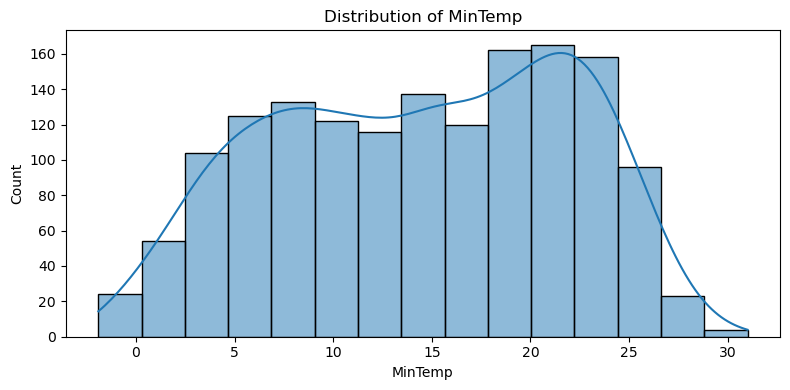

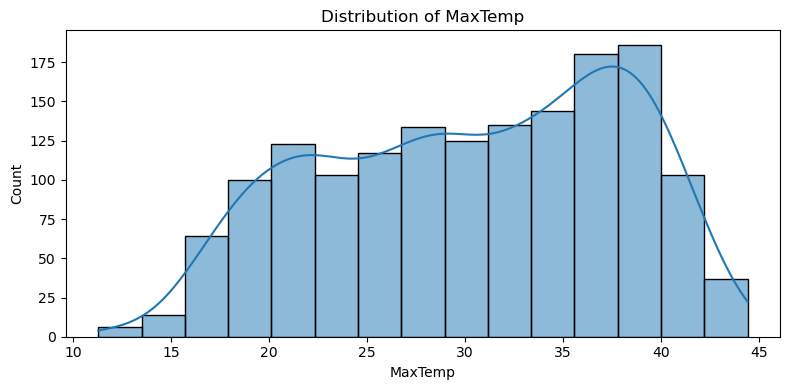

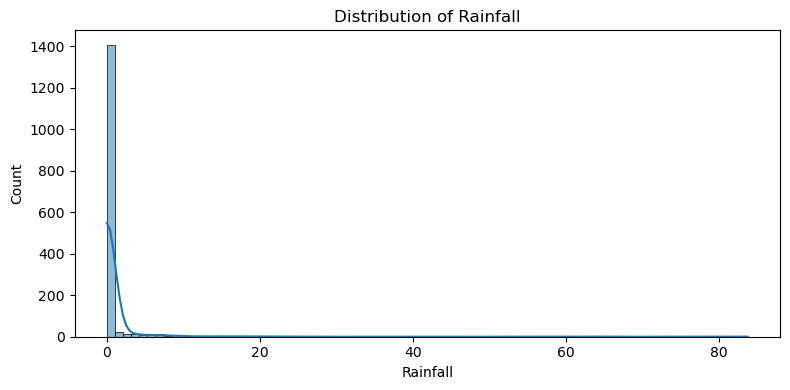

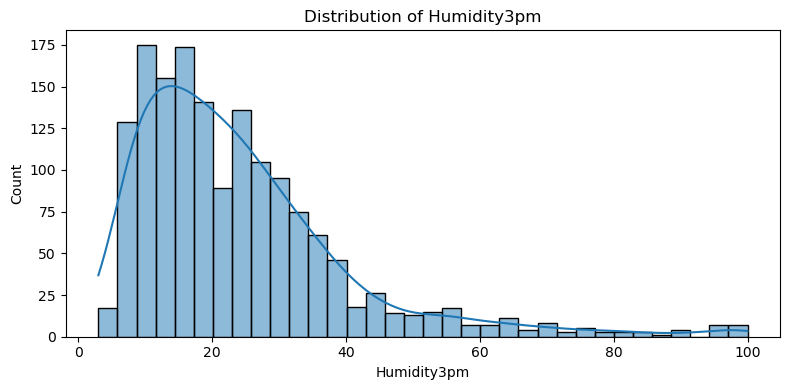

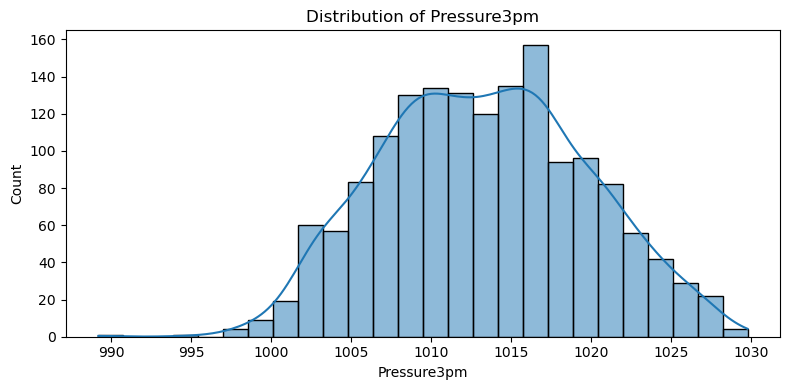

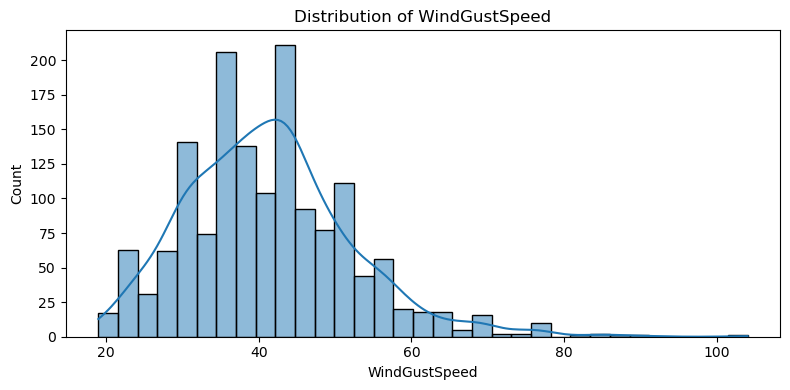

In [107]:
features = [ #imporant features, probably
    "MinTemp",
    "MaxTemp",
    "Rainfall",
    "Humidity3pm",
    "Pressure3pm",
    "WindGustSpeed"
]

for feature in features:
    if feature not in df.columns:
        continue

    plt.figure(figsize=(8, 4))
    sns.histplot(df[feature], kde=True)
    plt.title(f"Distribution of {feature}")
    plt.tight_layout()
    plt.show()


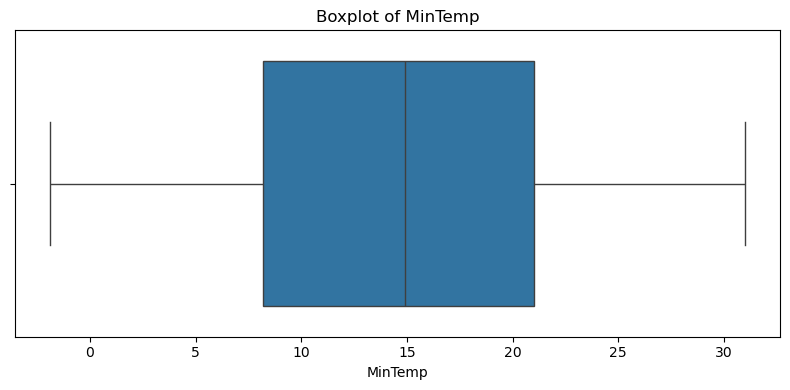

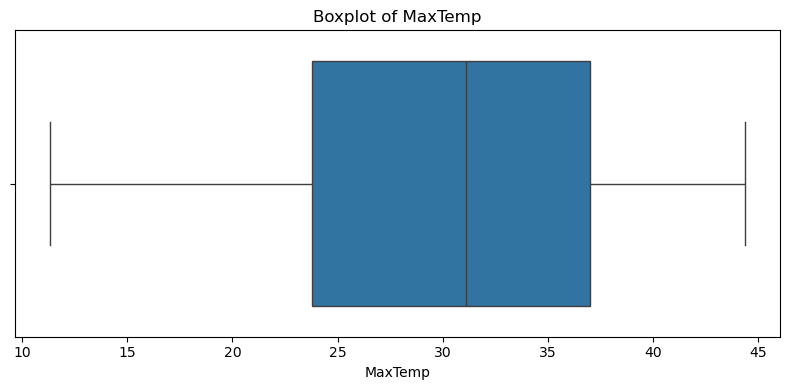

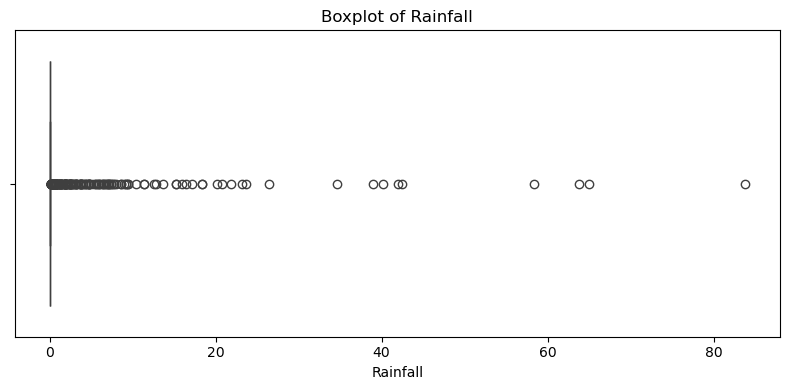

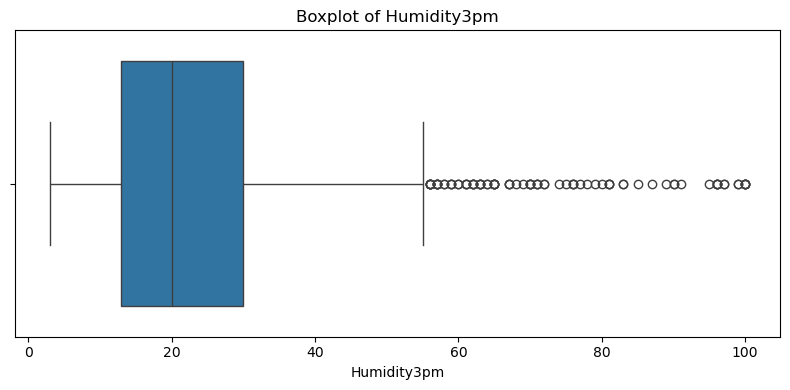

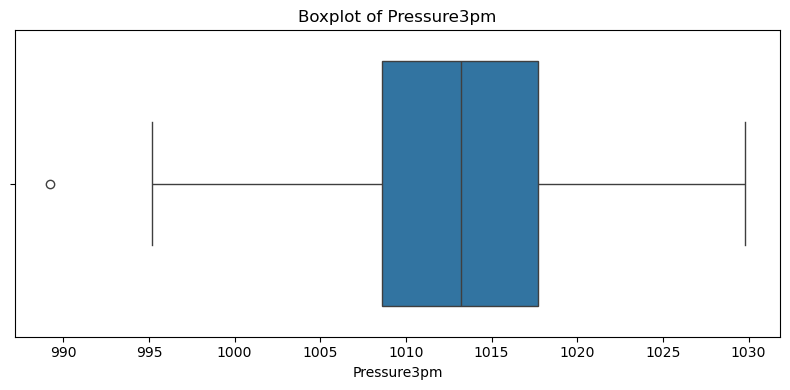

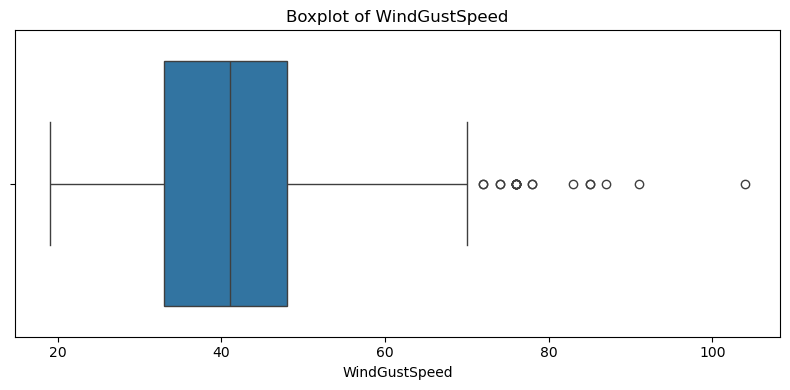

In [108]:
for feature in features:
        if feature not in df.columns:
            continue

        plt.figure(figsize=(8, 4))
        sns.boxplot(x=df[feature])
        plt.title(f"Boxplot of {feature}")
        plt.tight_layout()
        plt.show()

RainTomorrow
No     1405
Yes     116
Name: count, dtype: int64


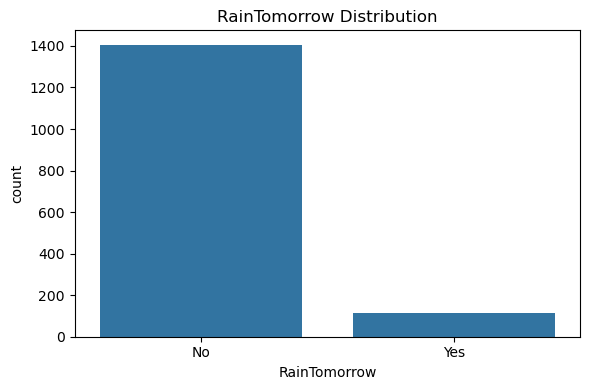

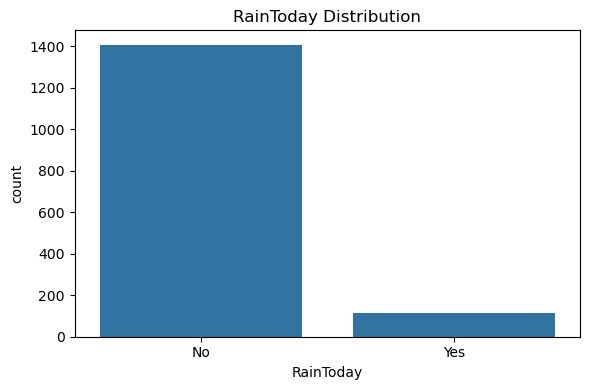


RainToday vs RainTomorrow
RainTomorrow    No  Yes
RainToday              
No            1313   76
Yes             74   39


In [109]:
print(df["RainTomorrow"].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="RainTomorrow")
plt.title("RainTomorrow Distribution")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="RainToday")
plt.title("RainToday Distribution")
plt.tight_layout()
plt.show()

print("\nRainToday vs RainTomorrow")

crosstab = pd.crosstab(
    df["RainToday"],
    df["RainTomorrow"]
)

print(crosstab)

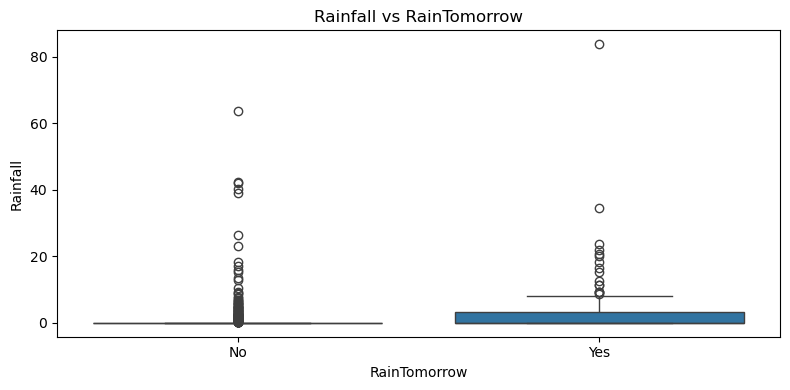

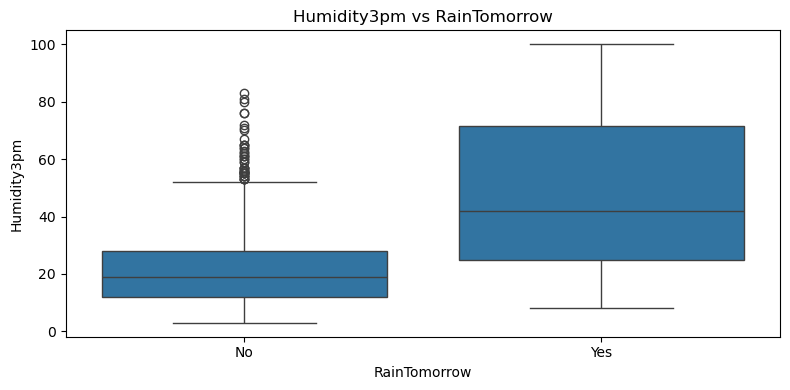

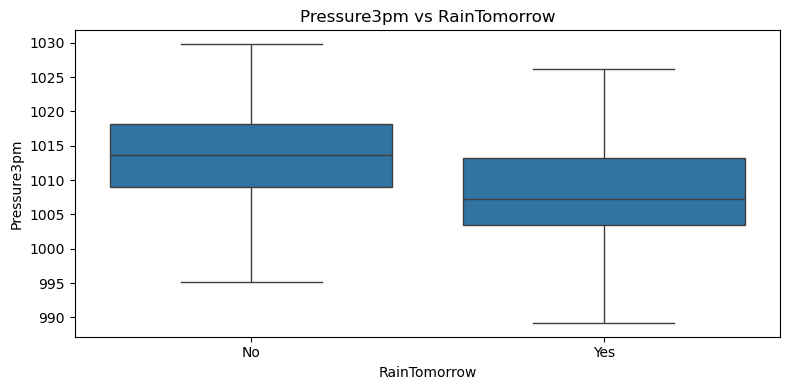

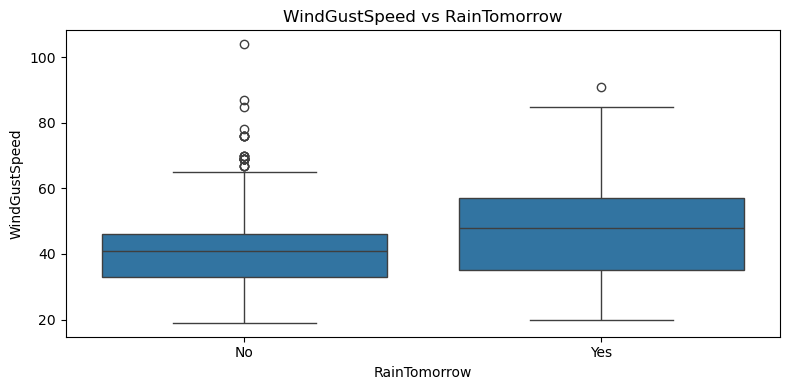

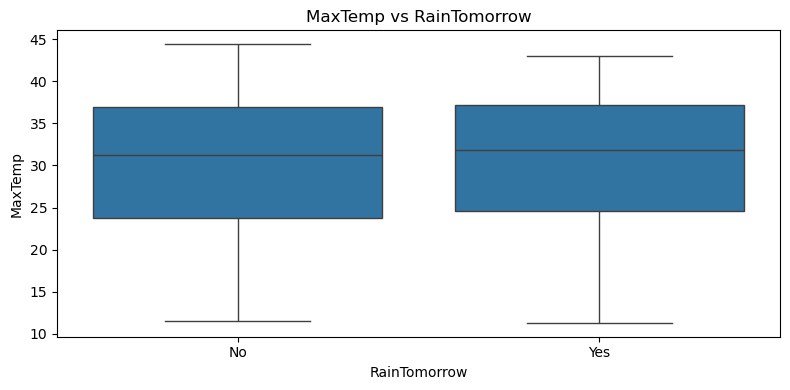

In [110]:
features = [
        "Rainfall",
        "Humidity3pm",
        "Pressure3pm",
        "WindGustSpeed",
        "MaxTemp"
    ]

for feature in features:
    if feature not in df.columns:
        continue

    plt.figure(figsize=(8, 4))
    sns.boxplot(
        data=df,
        x="RainTomorrow",
        y=feature
    )

    plt.title(f"{feature} vs RainTomorrow")
    plt.tight_layout()
    plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [111]:
def filter_location(df):
    return df[df["Location"] == "Uluru"].copy()

In [ ]:
def remove_duplicates(df):
    # print(df.head())
    before = len(df)
    df = df.drop_duplicates()
    after = len(df)
    print(f"Duplicates removed: {before - after}")
    return df

In [113]:
def remove_high_missing_columns(df, threshold=50):
    missing_percentage = df.isnull().mean() * 100

    cols_to_drop = missing_percentage[
        missing_percentage > threshold
    ].index.tolist()

    print("\nColumns dropped (>50% missing):")
    print(cols_to_drop)

    df = df.drop(columns=cols_to_drop)

    return df

In [114]:
def convert_date_features(df):
    df["Date"] = pd.to_datetime(df["Date"])

    df["Year"] = df["Date"].dt.year
    df["Month"] = df["Date"].dt.month
    df["Day"] = df["Date"].dt.day

    df = df.drop(columns=["Date"])

    return df

In [115]:
def handle_missing_values(df):
    numerical_columns = df.select_dtypes(
        include=np.number
    ).columns

    categorical_columns = df.select_dtypes(
        exclude=np.number
    ).columns

    for col in numerical_columns:
        median_value = df[col].median()
        df[col] = df[col].fillna(median_value)

    for col in categorical_columns:
        mode_value = df[col].mode()[0]
        df[col] = df[col].fillna(mode_value)

    return df

In [116]:
def encode_categorical_features(df):
    categorical_columns = df.select_dtypes(
        include="object"
    ).columns

    encoders = {}

    for col in categorical_columns:
        encoder = LabelEncoder()

        df[col] = encoder.fit_transform(df[col])

        encoders[col] = encoder

    return df, encoders

In [117]:
def detect_outliers_iqr(df):
    numerical_columns = df.select_dtypes(
        include=np.number
    ).columns

    for col in numerical_columns:

        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)

        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        df[col] = np.where(
            df[col] < lower_bound,
            lower_bound,
            df[col]
        )

        df[col] = np.where(
            df[col] > upper_bound,
            upper_bound,
            df[col]
        )

    return df

In [118]:
def standardize_features(df):
    scaler = StandardScaler()

    target_column = "RainTomorrow"

    feature_columns = [
        col for col in df.columns
        if col != target_column
    ]

    df[feature_columns] = scaler.fit_transform(
        df[feature_columns]
    )

    return df, scaler

In [119]:
def preprocessing_pipeline(filepath):
    print("Loading data...")
    df = load_dataset(filepath)
    
    print("Filtering Uluru...")
    df = filter_location(df)

    print("Removing duplicates...")
    df = remove_duplicates(df)

    print("Removing high-missing columns...")
    df = remove_high_missing_columns(df)

    print("Creating date features...")
    df = convert_date_features(df)

    print("Handling missing values...")
    df = handle_missing_values(df)

    print("Encoding categorical features...")
    df, encoders = encode_categorical_features(df)

    print("Handling outliers...")
    df = detect_outliers_iqr(df)

    print("Standardizing features...")
    df, scaler = standardize_features(df)

    print("\nFinal Shape:")
    print(df.shape)

    return df

In [120]:
processed_df = preprocessing_pipeline("../weatherAUS_raw.csv")

processed_df.to_csv(
    "weatherAUS_uluru_preprocessed.csv",
    index=False
)

print(
    f"\nPreprocessed dataset saved to: ../weatherAUS_raw.csv"
)

Loading data...
Filtering Uluru...
Removing duplicates...
              Date Location  MinTemp  MaxTemp  Rainfall  Evaporation  \
143882  2013-03-01    Uluru     19.7     30.0       0.8          NaN   
143883  2013-03-02    Uluru     21.6     33.1       0.0          NaN   
143884  2013-03-03    Uluru     21.3     36.1       0.0          NaN   
143885  2013-03-04    Uluru     22.9     37.7       0.0          NaN   
143886  2013-03-05    Uluru     24.0     39.0       0.0          NaN   

        Sunshine WindGustDir  WindGustSpeed WindDir9am  ... Humidity9am  \
143882       NaN         ESE           48.0          E  ...        76.0   
143883       NaN           E           33.0          E  ...        44.0   
143884       NaN           E           33.0        ENE  ...        39.0   
143885       NaN         ENE           39.0          E  ...        35.0   
143886       NaN           S           39.0          E  ...        33.0   

        Humidity3pm  Pressure9am  Pressure3pm  Cloud9am  C

C:\Users\I Made Riana\AppData\Local\Temp\ipykernel_10400\786627318.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(
